In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [3]:
np.random.seed(42)

dates = pd.date_range(start="2024-01-01", end="2024-12-31", freq="D")
books = [
    ("B001", "Data Science for Beginners"),
    ("B002", "Advanced Python Analytics"),
    ("B003", "AI in Publishing"),
]

platforms = ["Amazon", "Barnes & Noble", "Apple Books"]
formats = ["ebook", "paperback", "hardcover"]
countries = ["US", "UK", "CA", "AU"]
campaigns = ["Amazon Ads", "Facebook Ads", "Organic"]

rows = []

for date in dates:
    for book_id, title in books:
        rows.append({
            "date": date,
            "book_id": book_id,
            "title": title,
            "author": "Jane Doe",
            "format": np.random.choice(formats, p=[0.5, 0.3, 0.2]),
            "platform": np.random.choice(platforms, p=[0.6, 0.25, 0.15]),
            "country": np.random.choice(countries, p=[0.6, 0.2, 0.1, 0.1]),
            "units_sold": np.random.poisson(lam=8),
            "list_price": np.random.choice([4.99, 9.99, 19.99]),
            "royalty_rate": np.random.choice([0.35, 0.7]),
            "production_cost": np.random.uniform(0.5, 2.0),
            "marketing_cost": np.random.uniform(0, 5),
            "ad_campaign": np.random.choice(campaigns, p=[0.4, 0.3, 0.3]),
            "ad_clicks": np.random.randint(0, 200),
            "ad_spend": np.random.uniform(0, 20),
            "kenp_pages_read": np.random.randint(0, 1200)
        })

df = pd.DataFrame(rows)


In [4]:
df["gross_revenue"] = df["units_sold"] * df["list_price"]
df["royalty_earnings"] = df["gross_revenue"] * df["royalty_rate"]
df["total_cost"] = df["production_cost"] + df["marketing_cost"] + df["ad_spend"]
df["net_profit"] = df["royalty_earnings"] - df["total_cost"]

df["month"] = df["date"].dt.to_period("M")
df["year"] = df["date"].dt.year


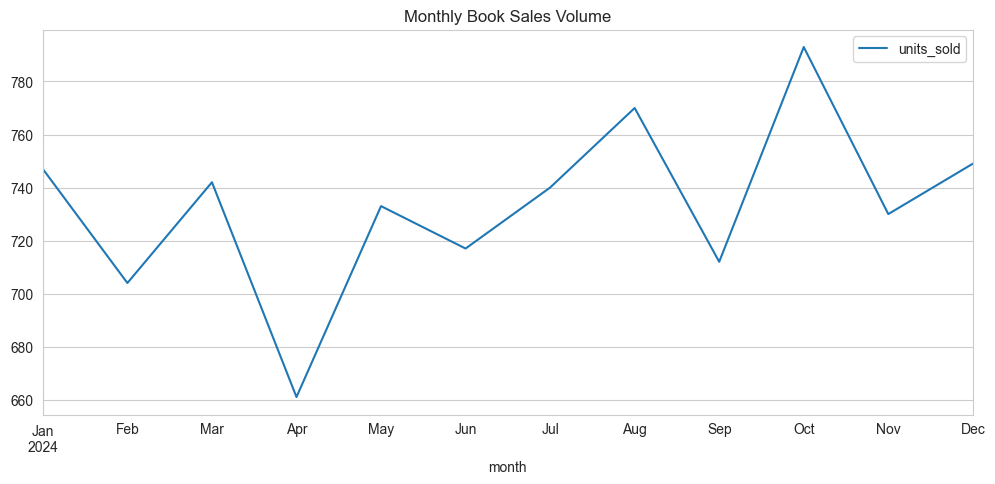

In [5]:
monthly_sales = (
    df.groupby("month")["units_sold"]
    .sum()
    .reset_index()
)

monthly_sales.plot(
    x="month",
    y="units_sold",
    figsize=(12, 5),
    title="Monthly Book Sales Volume"
)
plt.show()


In [6]:
platform_perf = (
    df.groupby("platform")[["units_sold", "net_profit"]]
    .sum()
    .sort_values("units_sold", ascending=False)
)

platform_perf


,units_sold,net_profit
platform,,
Amazon,5448,24371.357572
Barnes & Noble,2177,9682.231167
Apple Books,1173,5508.132106


In [7]:
kenp_analysis = (
    df.groupby("title")["kenp_pages_read"]
    .sum()
    .reset_index()
    .sort_values("kenp_pages_read", ascending=False)
)

kenp_analysis


,title,kenp_pages_read
0,AI in Publishing,223550
2,Data Science for Beginners,213399
1,Advanced Python Analytics,211920


In [8]:
df["conversion_rate"] = df["units_sold"] / df["ad_clicks"].replace(0, np.nan)
df["roi"] = (df["royalty_earnings"] - df["ad_spend"]) / df["ad_spend"].replace(0, np.nan)

roi_by_campaign = (
    df.groupby("ad_campaign")[["roi", "conversion_rate"]]
    .mean()
)

roi_by_campaign


,roi,conversion_rate
ad_campaign,,
Amazon Ads,13.984622,0.210962
Facebook Ads,13.371628,0.204989
Organic,13.581444,0.261011


In [9]:
profit_by_format = (
    df.groupby("format")[["gross_revenue", "net_profit"]]
    .sum()
)

profit_by_format


,gross_revenue,net_profit
format,,
ebook,52376.33,20134.312240
hardcover,21892.55,8331.383261
paperback,31313.14,11096.025343


In [10]:
monthly_profit = (
    df.groupby("month")["net_profit"]
    .sum()
    .reset_index()
)

monthly_profit["pct_change"] = monthly_profit["net_profit"].pct_change()

monthly_profit.tail()


,month,net_profit,pct_change
7,2024-08,3446.895162,0.183514
8,2024-09,3546.884581,0.029009
9,2024-10,3947.650682,0.112991
10,2024-11,3003.010724,-0.239292
11,2024-12,2998.112107,-0.001631
